# Payment Analytics

## Business Objective

The objective of this notebook is to analyze customer payment behavior, preferred payment methods, installment usage, and payment value distribution to generate financial insights and support business decision-making.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
payments = pd.read_csv("../data/engineered/payments_engineered.csv")
orders = pd.read_csv("../data/engineered/orders_engineered.csv")

In [3]:
payments.shape, orders.shape

((103886, 6), (99441, 14))

## Payment Method Distribution

In [4]:
payment_methods = (
    payments["payment_category"]
    .value_counts()
)

payment_methods

Card             78324
Bank Transfer    19784
Voucher           5775
not_defined          3
Name: payment_category, dtype: int64

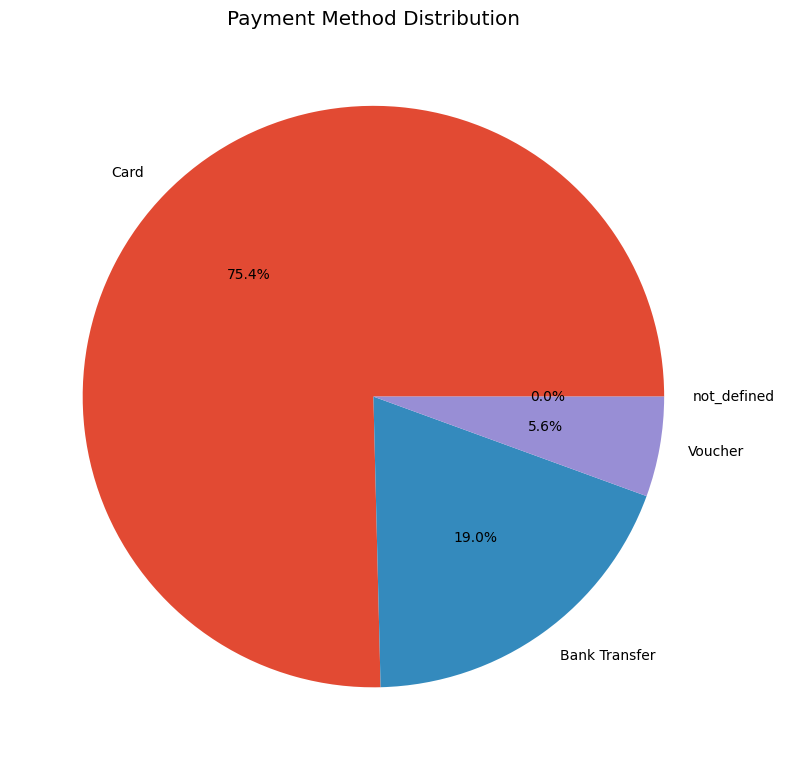

In [5]:
plt.figure(figsize=(8,8))

payment_methods.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Payment Method Distribution")

plt.tight_layout()

plt.show()

Digital card payments account for the majority of transactions, indicating strong customer preference for electronic payment methods. Alternative payment methods contribute a smaller share of total transactions.

## Average Payment Value

In [6]:
average_payment = payments["payment_value"].mean()

print(f"Average Payment Value: R$ {average_payment:,.2f}")

Average Payment Value: R$ 154.10


The average payment value provides a benchmark for evaluating customer purchasing behavior and monitoring changes in transaction size over time.

## Installment Distribution

In [7]:
installments = (
    payments["payment_installments"]
    .value_counts()
    .sort_index()
)

installments

0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: payment_installments, dtype: int64

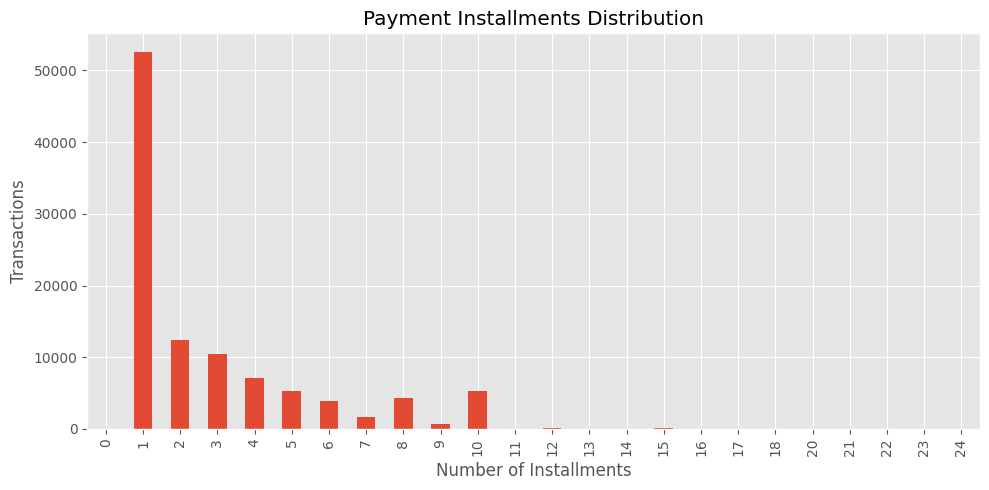

In [8]:
plt.figure(figsize=(10,5))

installments.plot(
    kind="bar"
)

plt.title("Payment Installments Distribution")

plt.xlabel("Number of Installments")

plt.ylabel("Transactions")

plt.tight_layout()

plt.show()

Most customers prefer paying in fewer installments, while a smaller proportion choose long-term installment plans. This information supports financial planning and promotional strategies.

## Payment Value Distribution

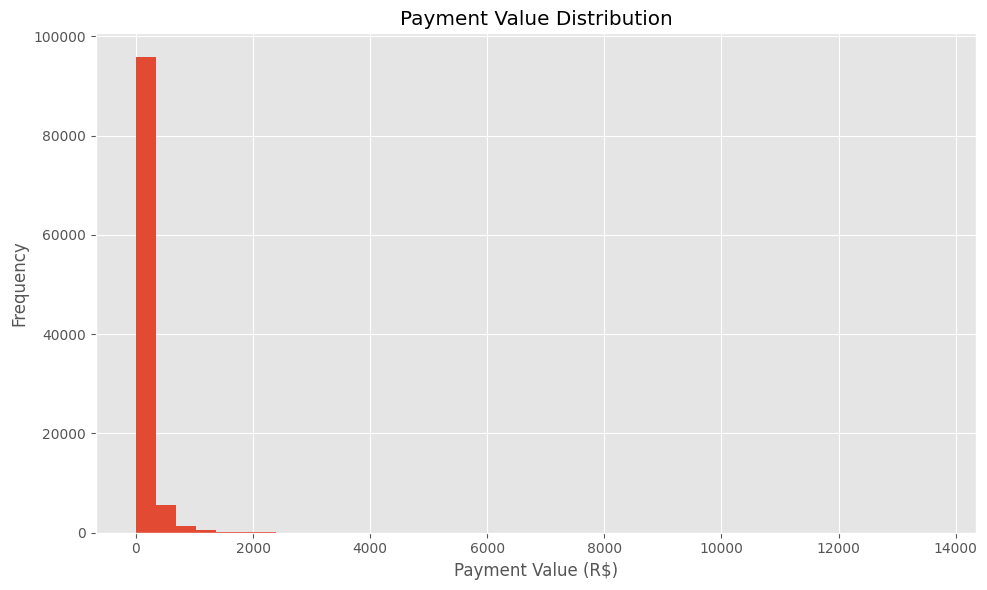

In [9]:
plt.figure(figsize=(10,6))

payments["payment_value"].plot(
    kind="hist",
    bins=40
)

plt.title("Payment Value Distribution")
plt.xlabel("Payment Value (R$)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

Most transactions are concentrated in lower payment value ranges, while only a small proportion of customers make high-value payments. This reflects a predominantly mid-to-low transaction marketplace with occasional premium purchases.

## Revenue by Payment Method

In [10]:
payment_revenue = (
    payments
    .groupby("payment_category")
    .agg(
        TotalRevenue=("payment_value","sum")
    )
    .sort_values("TotalRevenue",ascending=False)
)

payment_revenue

,TotalRevenue
payment_category,
Card,12760073.98
Bank Transfer,2869361.27
Voucher,379436.87
not_defined,0.00


<Figure size 800x500 with 0 Axes>

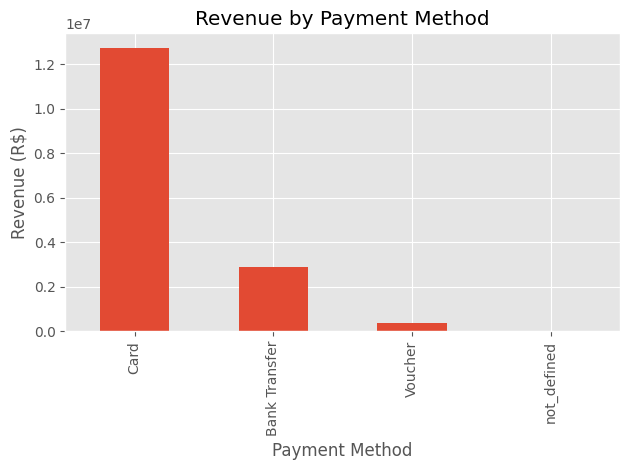

In [11]:
plt.figure(figsize=(8,5))

payment_revenue.plot(
    kind="bar",
    legend=False
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue (R$)")

plt.tight_layout()

plt.show()

Card payments generate the highest share of total revenue, reinforcing their importance as the primary payment channel. Alternative payment methods contribute comparatively less revenue.

## Average Payment Value by Payment Method

In [12]:
avg_payment = (
    payments
    .groupby("payment_category")
    .agg(
        AveragePayment=("payment_value","mean")
    )
    .sort_values("AveragePayment",ascending=False)
)

avg_payment

,AveragePayment
payment_category,
Card,162.913972
Bank Transfer,145.034435
Voucher,65.703354
not_defined,0.000000


<Figure size 800x500 with 0 Axes>

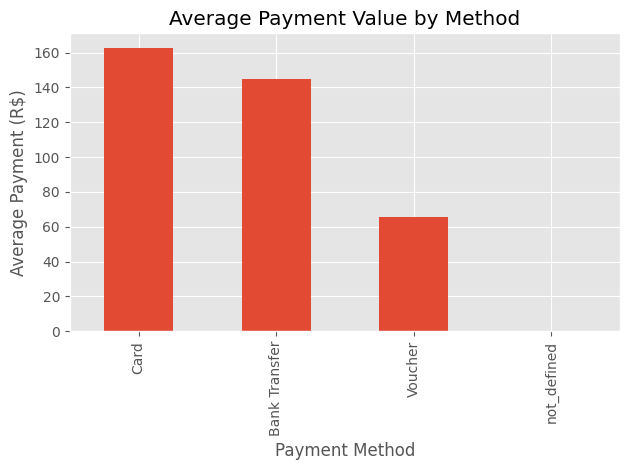

In [13]:
plt.figure(figsize=(8,5))

avg_payment.plot(
    kind="bar",
    legend=False
)

plt.title("Average Payment Value by Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Payment (R$)")

plt.tight_layout()

plt.show()

Although card payments dominate transaction volume, comparing average payment values across methods reveals differences in customer spending behavior and preferred payment channels.

# Key Insights

- Card payments dominate both transaction volume and revenue generation.
- The average payment value is approximately R$154, indicating moderate transaction sizes.
- Most customers prefer paying in one or a few installments.
- High installment plans are relatively uncommon.
- Payment values are concentrated in lower ranges with a long-tail distribution.
- Payment method preferences highlight strong adoption of electronic payments.

# Business Recommendations

- Prioritize secure and seamless card payment experiences.
- Offer installment promotions during seasonal campaigns to encourage larger purchases.
- Monitor payment behavior to identify fraud or unusual transaction patterns.
- Optimize checkout by emphasizing customers' preferred payment methods.
- Analyze installment trends regularly to improve financing strategies.